# Testing different hyperparmaters

In [44]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
from main import FirnModel
import xarray as xr
import hvplot.xarray as hv

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import matplotlib.pyplot as plt
import numpy as np
from xarray_sweep import xarray_sweep

In [46]:

def nu(t):
    step_time = 2
    nu = np.ones_like(t)
    nu[t>=step_time] = 1.2
    return nu

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.501 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids


<xarray.Dataset> Size: 8MB
Dimensions:       (z_h: 201, t: 369, z_r: 241)
Coordinates:
  * z_h           (z_h) float64 2kB 0.0 0.005 0.01 0.015 ... 0.99 0.995 1.0
  * t             (t) float64 3kB 0.0 0.007537 0.01504 ... 3.983 3.997 4.0
    z             (z_h, t) float64 593kB 0.0 0.0 0.0 0.0 ... 1.232 1.234 1.235
  * z_r           (z_r) float64 2kB 0.0 0.005 0.01 0.015 ... 1.19 1.195 1.2
Data variables: (12/18)
    phi           (z_h, t) float64 593kB 0.5 0.5 0.5 ... 5.817e-07 5.773e-07
    r2            (z_h, t) float64 593kB 0.0002857 0.0002857 ... 0.92 0.9205
    rho           (z_h, t) float64 593kB 459.0 459.0 459.0 ... 918.0 918.0 918.0
    A             (z_h, t) float64 593kB 0.0 0.0 0.0 ... 0.9568 0.9591 0.9596
    T             (z_h, t) float64 593kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    w             (z_h, t) float64 593kB 2.0 2.0 2.0 2.0 ... 1.201 1.201 1.201
    ...            ...
    phi_r         (z_r, t) float64 711kB 0.5 0.5 0.5 ... 9.05e-07 9.05e-07
    rho_r         (z_r, t) float64 711kB 459.0 459.0 459.0 ... 918.0 918.0 918.0
    r2_r          (z_r, t) float64 711kB 0.0002857 0.0002857 ... 0.8937 0.8937
    A_r           (z_r, t) float64 711kB 0.0 0.0 0.0 ... 0.9305 0.9305 0.9305
    T_r           (z_r, t) float64 711kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    w_r           (z_r, t) float64 711kB 2.0 2.0 2.0 2.0 ... 1.201 1.201 1.201
Attributes:
    simulation_parameters:  {'sim_label': 'default_label', 'b0_mpy': 0.1, 'be...

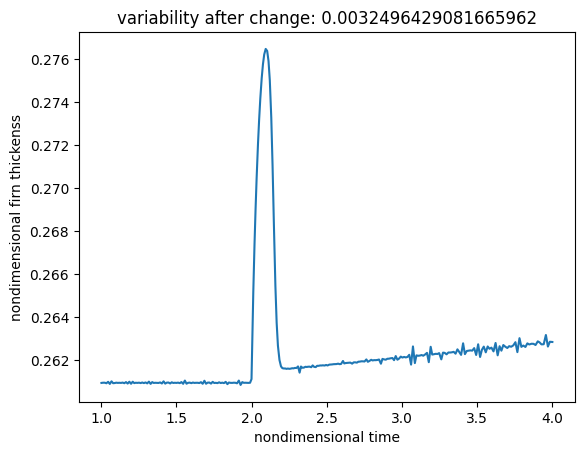

In [ ]:
fs2 = FirnModel()


out = fs2.setup(nu=nu, r_s_dim = 2.5e-09, interp_on_reg_z = True, simDuration = 4, Z = 1, dz = 0.005).run()
out.z830.where(out.t>1).plot()
plt.title(f"variability after change: {out.z830.where(out.t>2).std().values}")
out

In [5]:
def should_be_zero(method = "RK45", dz=0.01, Z=1, rtol = 1e-3, atol = 1e-6):
    out = fs2.setup(nu=nu, r_s_dim = 2.5e-09, interp_on_reg_z = True, simDuration = 8, Z = Z, dz = dz, rtol = rtol).run()
    z380 = out.where(out.t>3).z830

    slope, intercept = z380.polyfit(dim="t", deg=1).polyfit_coefficients.values

    detrended = z380 - np.polyval([slope,intercept], z380["t"].values)

    SD = detrended.std().values

    ds = xr.Dataset(
        data_vars=dict(
            SD=([], SD),
            slope=([], slope),
            elapsed_time=([], out.elapsed_time.values)
        ),
        coords=dict(
            dz=([], dz),
            Z=([], Z),
        ))

    return ds

In [97]:
should_be_zero(0.02, 1)

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.114 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids


<xarray.Dataset> Size: 40B
Dimensions:       ()
Coordinates:
    dz            float64 8B 0.02
    Z             int64 8B 1
Data variables:
    SD            float64 8B 0.0002929
    slope         float64 8B 0.003039
    elapsed_time  float64 8B 0.1135

In [7]:
A= xarray_sweep(should_be_zero, dz=np.logspace(-2.4, -2, 10), Z=np.array([1, ]))

  0%|          | 0/10 [00:00<?, ?it/s]

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  1.17 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.765 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.678 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.573 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.677 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** St

/Users/jkingslake/Documents/science/firn_accumulation/firn_transient/notebooks/../main.py:678: RuntimeWarning: overflow encountered in multiply
  v_int = -(H / Ar) * sigma**n * phi**m * np.exp(lambda_c * T) / r2
/Users/jkingslake/Documents/science/firn_accumulation/firn_transient/.venv/lib/python3.13/site-packages/scipy/integrate/_quadrature.py:336: RuntimeWarning: invalid value encountered in add
  res = xp.cumulative_sum(d * (y[slice1] + y[slice2]) / 2.0, axis=axis)


*** Successfully finished integration in  0.466 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.348 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.251 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.222 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids


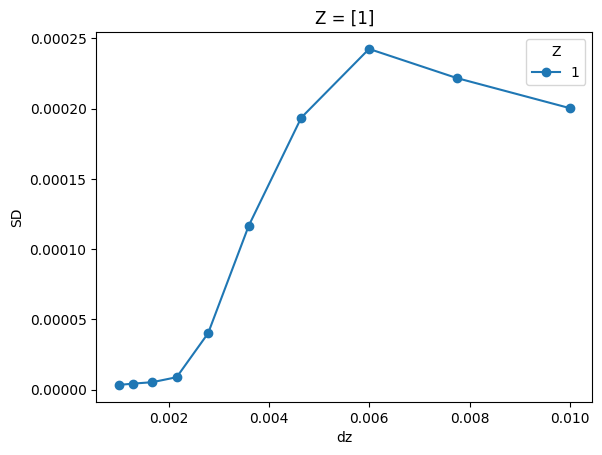

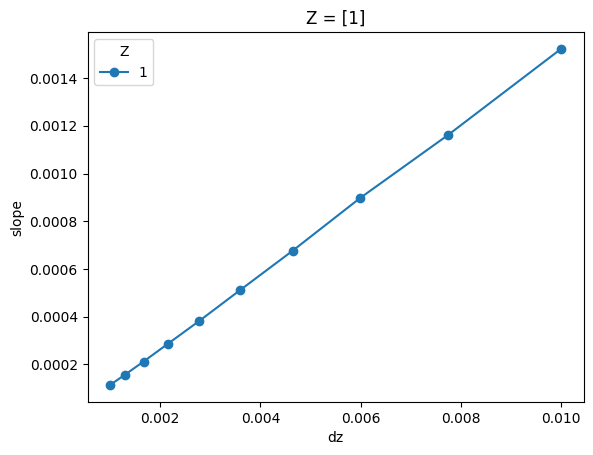

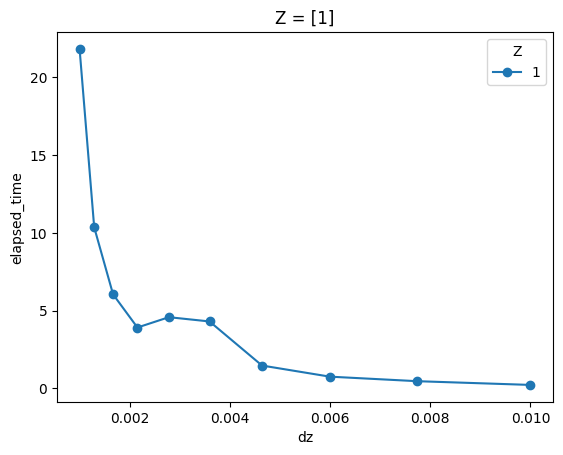

In [106]:
A.SD.plot(x="dz", hue="Z", marker="o")
plt.show()
A.slope.plot(x="dz", hue="Z", marker="o")
plt.show()
A.elapsed_time.plot(x="dz", hue="Z", marker="o")
plt.show()


In [43]:
A = xarray_sweep(should_be_zero, method = ["RK45", "DOP853" ], dz=np.logspace(-2.4, -1.8, 3), rtol = np.linspace(1e-4, 1e-2, 3), atol = np.linspace(1e-7, 1e-5, 3))

  0%|          | 0/54 [00:00<?, ?it/s]

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  1.54 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  1.12 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  1.06 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  1.09 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  1.21 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids
*** Starting setup.
*** Setup complete.
*** Starti

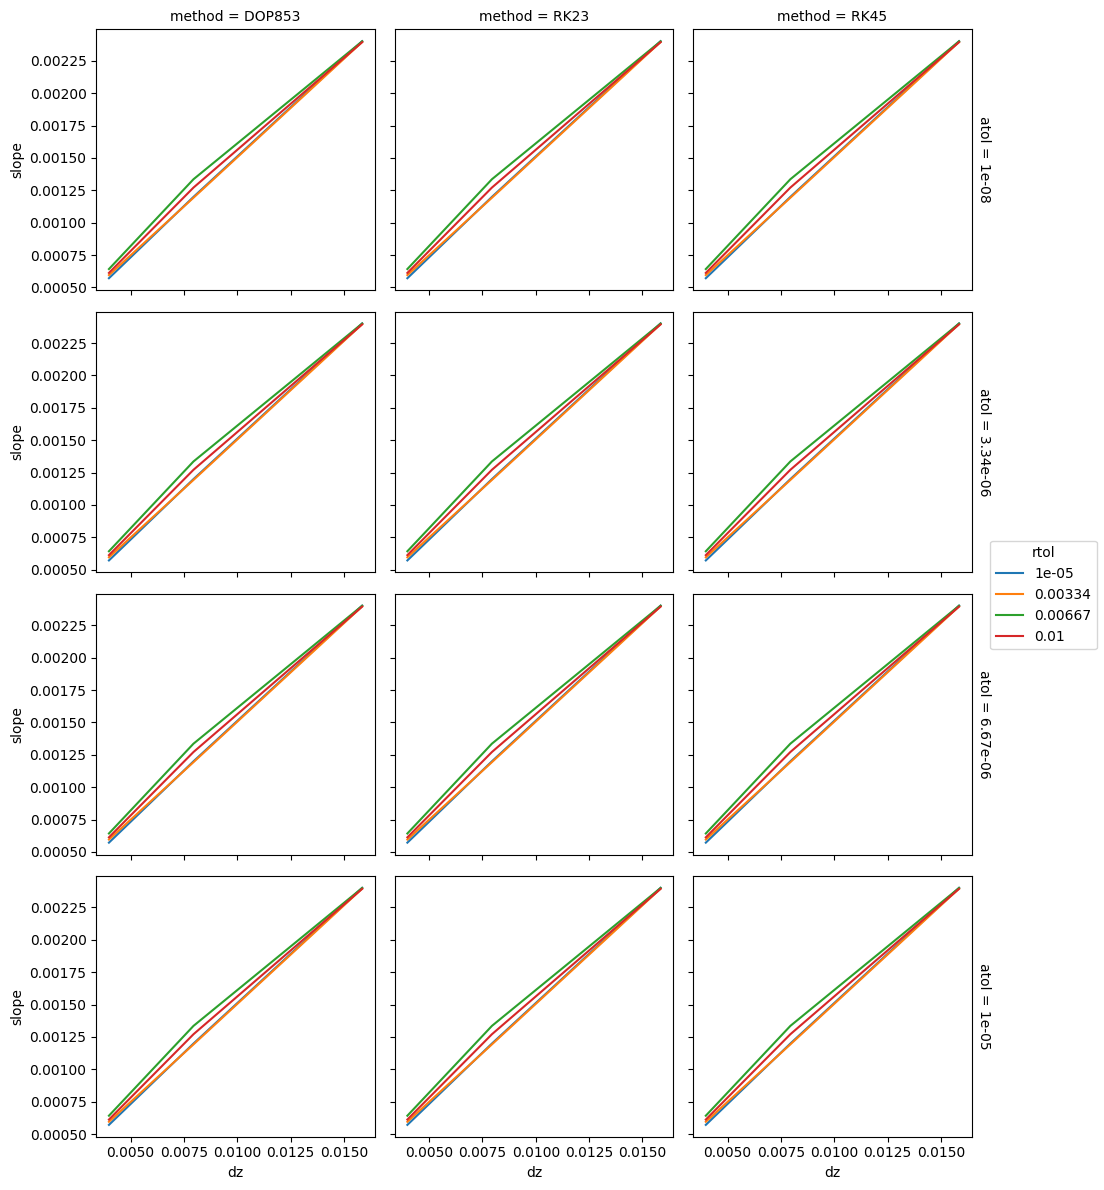

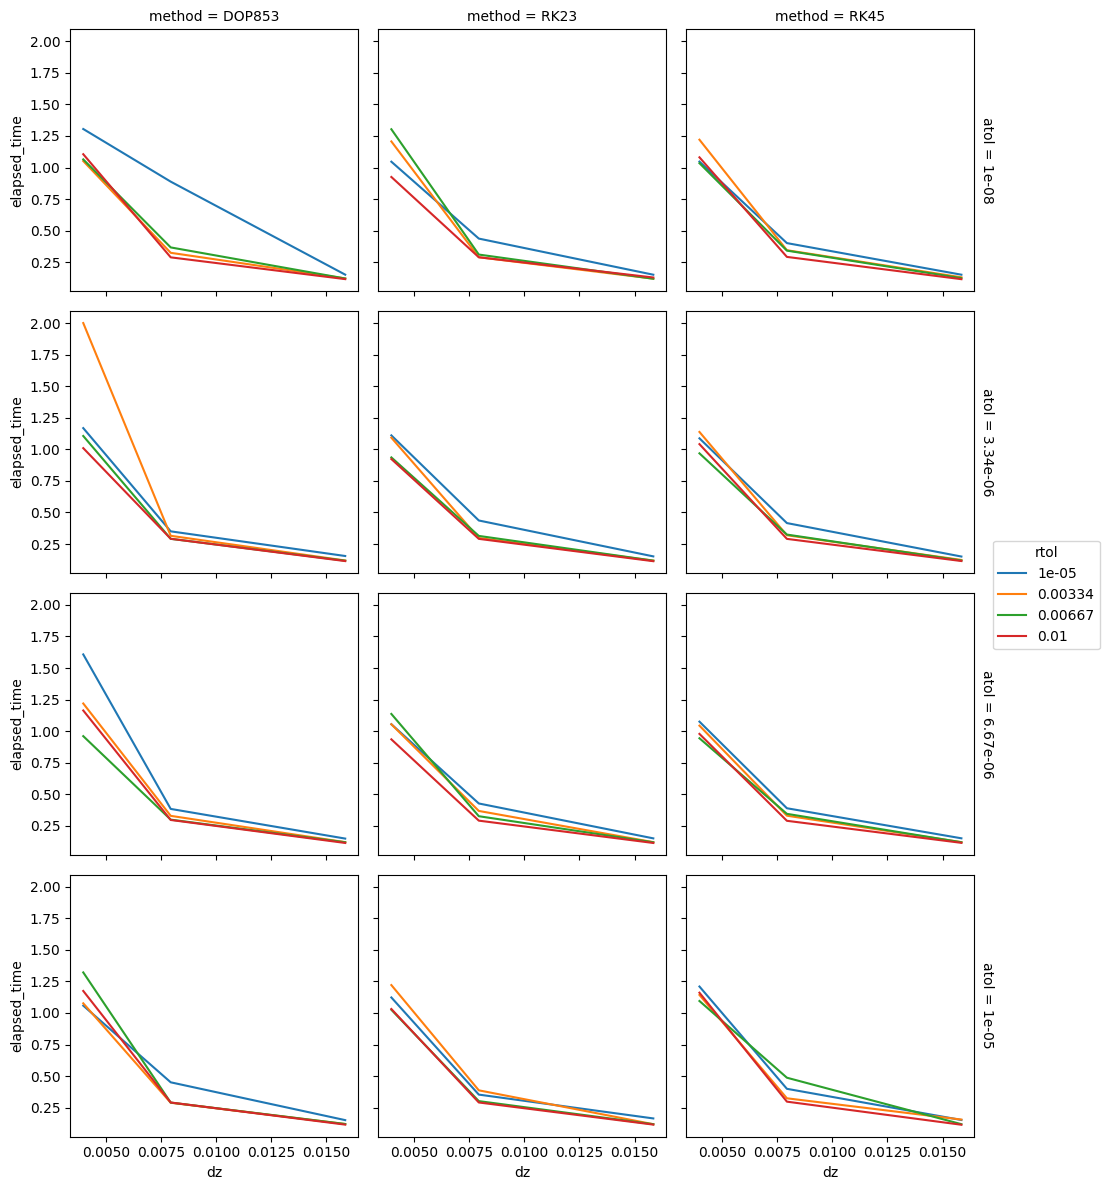

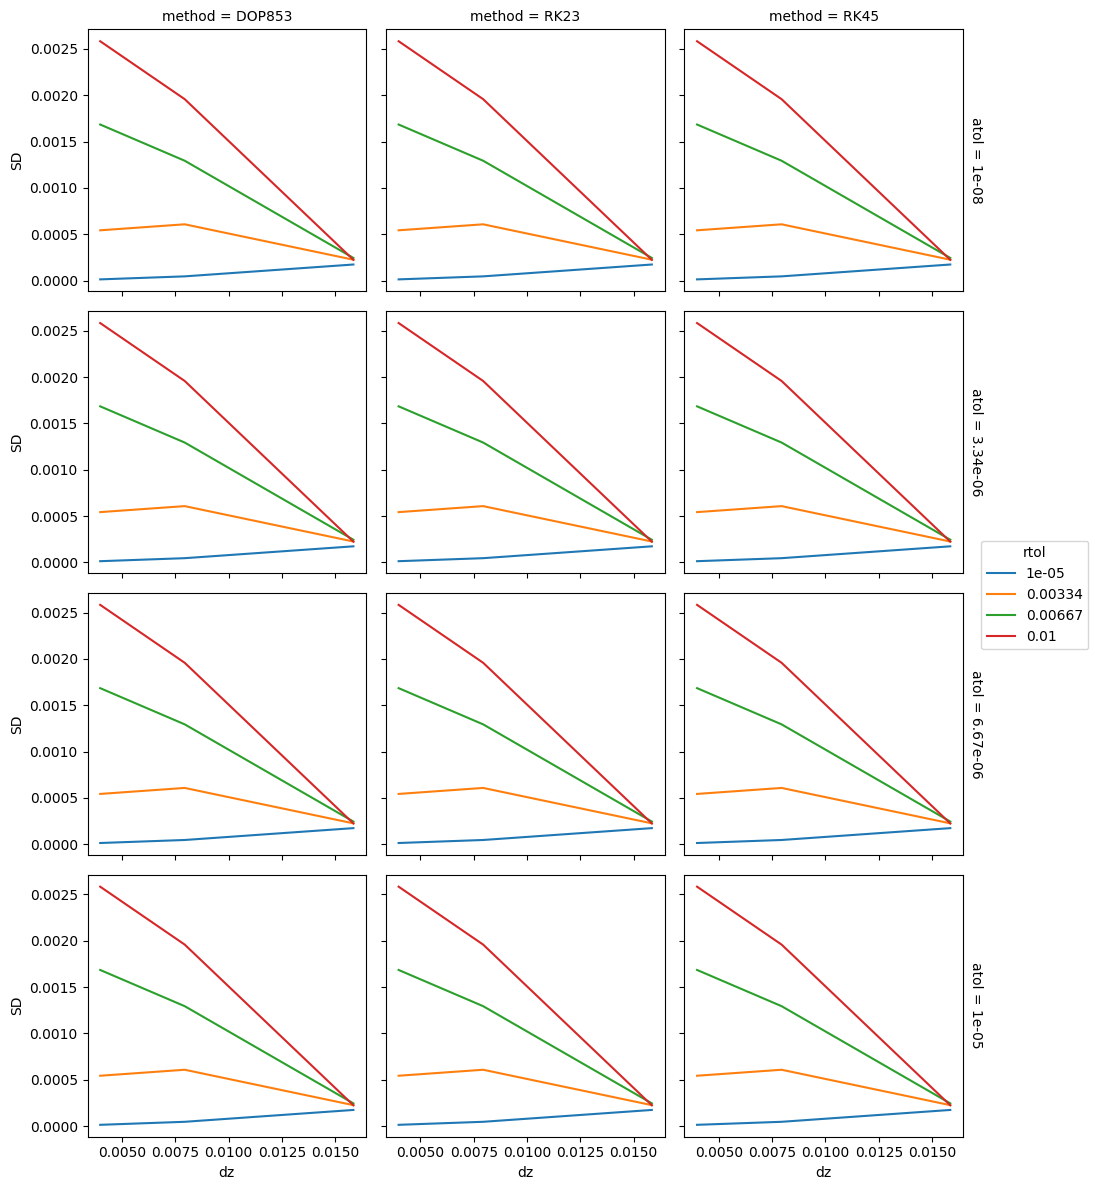

In [28]:
A.slope.plot(col = "method", x="dz", row="atol", hue="rtol");
plt.show()
A.elapsed_time.plot(col = "method", x="dz", row="atol", hue="rtol");
plt.show()
A.SD.plot(col = "method", x="dz", row="atol", hue="rtol");
plt.show()
